In [1]:
import os
import copy
from collections import defaultdict
import itertools

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '../../.')
from McCauley_utils import all_data

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io

from scLEMBAS.metrics import distances 

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PLSRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [3]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

merged_adatas = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_model_predictions.pickle'.format(author))
)
for v in  merged_adatas.values():
    v.obs_names_make_unique()

cspm_ = io.read_pickled_object(os.path.join(data_path, 'interim', '{}_test_condition_PLS_models.pickle'.format(author)))

# format for input to emd loss function
cspm = {}
for fold in range(5):
    split = get_split(fold, author)
    test_conds = split['test_conds']
    for test_cond in test_conds:
        cspm[test_cond] = copy.deepcopy(cspm_[fold])

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS_v2/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PLSRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
def load_test_tfadata(fold, key):
    key_ = '{}_{}'.format(key, fold)
    tf_adata_merged = merged_adatas[key_].copy()
        
    split = get_split(fold, author)
    test_conds = split['test_conds']

    test_cond_mask = tf_adata_merged.obs.condition.isin(test_conds)
    tf_adata_test = tf_adata_merged[test_cond_mask,:].copy()
    assert 'predicted_ctrl' not in tf_adata_test.obs.batch, 'Unexpected training predictions present'
    
    predicted_mask = (tf_adata_test.obs.batch == 'predicted')
    tf_adata_predicted = tf_adata_test[predicted_mask, :].copy()    
    tf_adata_actual = tf_adata_test[~predicted_mask, :].copy()
    assert len(np.where(tf_adata.obs.condition.isin(test_conds))[0]) == tf_adata_actual.shape[0], 'Incorrect subsetting of actual data'

    return tf_adata_actual, tf_adata_predicted

In [5]:
remove_types = [
    'none',
    ['adj', 'categorical_bias'],
    ['adj', 'global_bias'],
    'total_bias', 
    'adj',
    'categorical_bias',
    'global_bias'
]
remove_types = [rt if type(rt) != list else '^'.join(rt) for rt in remove_types]

ablated_components = {
    'none': 'None', 
    'global_bias': 'Global Bias', 
    'adj^global_bias': 'Adj + Global Bias', 
    'total_bias': 'Total Bias',
    'adj^categorical_bias': 'Adj + Categorical Bias', 
    'adj': 'Adjaceny Matrix Only', 
    'categorical_bias': 'Categorical Bias Only', 
                       }
remaining_components = {'none': 'Full Model', 
                        'global_bias': 'Adj + Categorical Bias', 
                        'adj^global_bias': 'Categorical Bias Only',
                        'total_bias': 'Adjaceny Matrix Only',
                       'adj^categorical_bias': 'Global Bias Only', 
                       'adj': 'Total Bias', 
                       'categorical_bias': 'Adj + Global Bias', 
                       }

ar_c = {}
for k,v  in ablated_components.items():
    ar_c[k] =  '{}\n({})'.format(ablated_components[k], remaining_components[k])
    
    
iterables = itertools.product(range(5), remove_types)


In [6]:
loss_dict = defaultdict(list)

for (fold, key) in iterables:
    print(fold)
    tf_adata_actual, tf_adata_predicted = load_test_tfadata(fold, key)
    
    for latent_models in [None, cspm]:
        emd_loss = distances.get_EMD_loss(
            tf_adata_actual, tf_adata_predicted, 
            groupby_col = 'condition', # per test condition
            latent_models = latent_models, 
                    )['Mean EMD Loss']


        loss_dict['Mean EMD Loss'].append(emd_loss)
        loss_dict['Space'].append('Full Feature Space' if latent_models is None else 'Test Condition Specific PLS Space')
        loss_dict['Fold'].append(fold + 1)
        loss_dict['Model Components'].append(key)

emd_loss = pd.DataFrame(loss_dict)
baseline = (
    emd_loss[emd_loss["Model Components"] == 'none']
    .set_index(["Space", "Fold"])["Mean EMD Loss"]
)

emd_loss["Normalized Mean EMD Loss"] = (
    emd_loss["Mean EMD Loss"]/ emd_loss.set_index(["Space", "Fold"]).index.map(baseline)
)

emd_loss.to_csv(os.path.join(data_path, 'processed', '{}_emd_loss_per_component.csv'))



0
0
0
0
0
0
0
1
1
1
1
1
1
1
2
2
2
2
2
2
2
3
3
3
3
3
3
3
4
4
4
4
4
4
4


In [7]:
emd_loss = pd.read_csv(os.path.join(data_path, 'processed', '{}_emd_loss_per_component.csv'), index_col = 0)

emd_loss['Model Components'] = pd.Categorical(
    emd_loss['Model Components'].map(ar_c), 
    ordered = True, 
    categories = list(ar_c.values())
)


In [8]:
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

In [9]:
def component_dist_viz(
    space, 
    fig_name = None, 
    show_fig = True
):

    fig, ax = plt.subplots(figsize = (5, 5), constrained_layout = True)

    viz_df = emd_loss[emd_loss.Space == space].copy()
    viz_df['Model Components'] = viz_df['Model Components'][~viz_df['Model Components'].isin([ar_c['none']])].cat.remove_unused_categories()
    viz_df = viz_df[viz_df['Model Components'].notna()].copy()


    sns.violinplot(data = viz_df, x = 'Model Components', y = 'Normalized Mean EMD Loss', ax = ax)
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    ax.set_title(space)
    ax.set_xlabel('Ablated Model Component(s)')
    
    if fig_name is not None:
        dirpath  = os.path.dirname(fig_name)
        basename = os.path.basename(fig_name)
        stem, _  = os.path.splitext(basename)
        out_base = os.path.join(dirpath, stem)
        
        plt.savefig(
            "{}.png".format(out_base),
            dpi=1200,
            bbox_inches="tight",
            transparent=True,
        )

        plt.savefig(
            "{}.svg".format(out_base),
            format="svg",
            bbox_inches="tight",
        )
        
    if show_fig:
        plt.show()
    ;

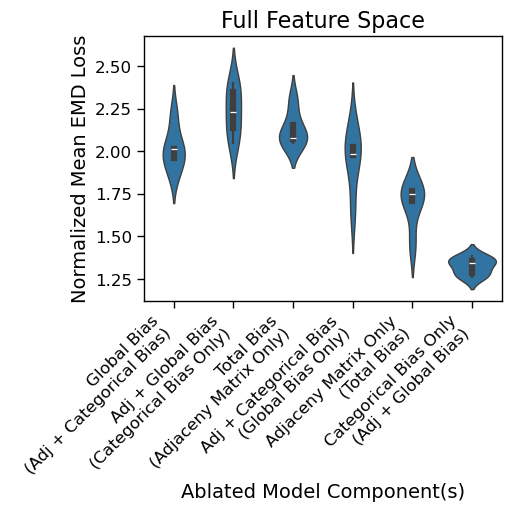

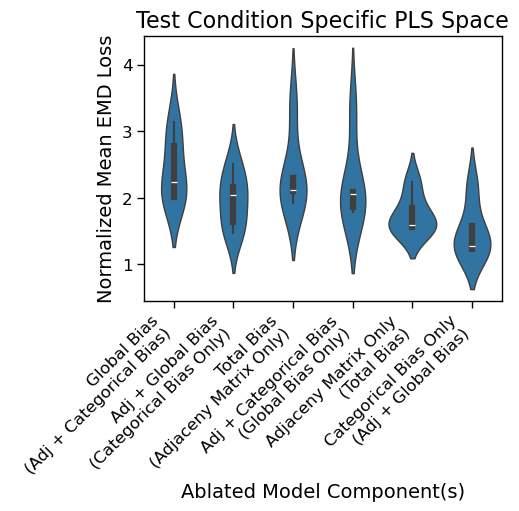

In [10]:
for space in ['Full Feature Space', 'Test Condition Specific PLS Space']:
    component_dist_viz(space = space, 
#                       fig_name = '{}_{}_per_component_loss_distributions'.format(author, space), 
                      show_fig = True)
    

/tmp/ipykernel_2581791/3746057343.py:20: PendingDeprecationWarning: The set_constrained_layout_pads function will be deprecated in a future version. Use figure.get_layout_engine().set() instead.
  fig.set_constrained_layout_pads(h_pad=0.15, w_pad=0.05, hspace=0.15)


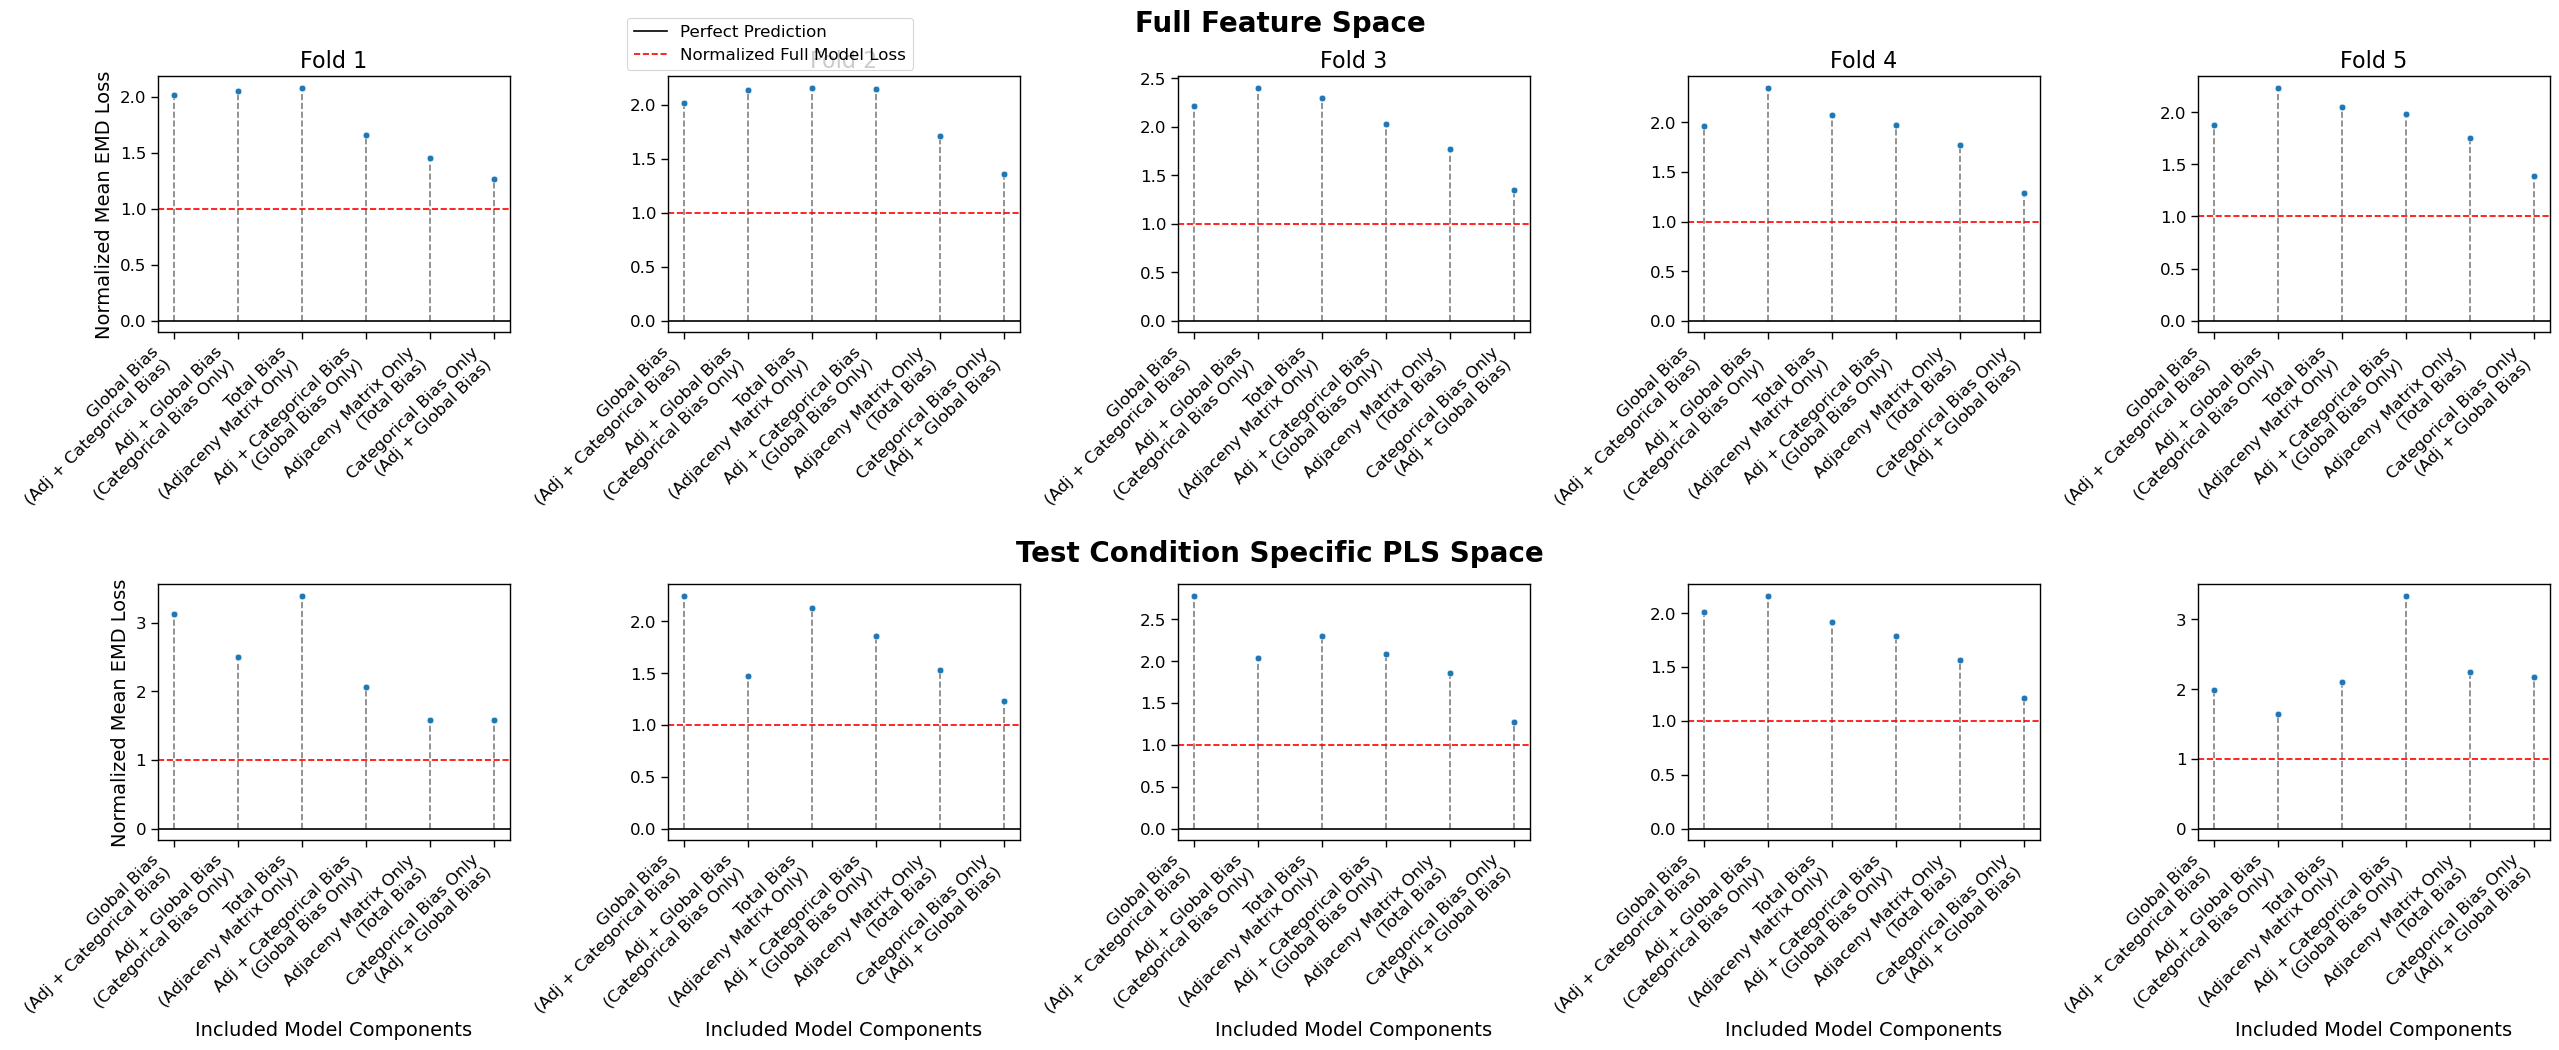

In [12]:


ncols = 5
nrows = 2
fig, ax = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    figsize=(5.1*ncols, 5.1*nrows),
    constrained_layout=True
)
fig.set_constrained_layout_pads(h_pad=0.15, w_pad=0.05, hspace=0.15)

row_spaces = [
    "Full Feature Space",
    "Test Condition Specific PLS Space"
]

for i, space in enumerate(row_spaces):

    # ---- IMPORTANT: filter per row ----
    viz_df = emd_loss[emd_loss.Space == space].copy()
    viz_df = viz_df[~viz_df["Model Components"].isin([ar_c['none']])].copy()
    viz_df["Model Components"] = viz_df["Model Components"].cat.remove_unused_categories()

    for j in range(ncols):
        fold = j + 1
        viz_df_fold = viz_df[viz_df.Fold == fold]

        sns.scatterplot(
            data=viz_df_fold,
            x="Model Components",
            y="Normalized Mean EMD Loss",
            ax=ax[i, j]
        )

        ax[i, j].tick_params(axis="x", rotation=45)
        for label in ax[i, j].get_xticklabels():
            label.set_ha("right")

        ax[i, j].axhline(y=0, color="black", label="Perfect Prediction")
        ax[i, j].axhline(y=1, color="red", linestyle="--", label="Normalized Full Model Loss")

        for x, y in zip(
            viz_df_fold["Model Components"],
            viz_df_fold["Normalized Mean EMD Loss"]
        ):
            ax[i, j].vlines(x, ymin=0, ymax=y, linestyle="dashed", color="gray", zorder=0)

        ax[i, j].set_title(f"Fold {fold}")
        ax[i, j].set_xlabel("Included Model Components")

        if (i, j) == (0, 0):
            ax[i, j].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        if j != 0:
            ax[i,j].set_ylabel('')
        if i != 1:
            ax[i,j].set_xlabel('')
        if i != 0:
            ax[i,j].set_title('')
            
            


# ---- shared legend (unchanged) ----
leg = ax[0, 0].get_legend()
handles = leg.legend_handles
labels = [t.get_text() for t in leg.get_texts()]

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.3, 1.025)
)
ax[0, 0].legend_.remove()

# ---- row-level "suptitles" ----
fig.text(0.5, 1.025, row_spaces[0], ha="center", va="top", fontsize=20, fontweight="bold")
fig.text(0.5, 0.505,  row_spaces[1], ha="center", va="top", fontsize=20, fontweight="bold")
;

/tmp/ipykernel_2581791/1204360334.py:19: PendingDeprecationWarning: The set_constrained_layout_pads function will be deprecated in a future version. Use figure.get_layout_engine().set() instead.
  fig.set_constrained_layout_pads(h_pad=0.15, w_pad=0.05, hspace=0.15)


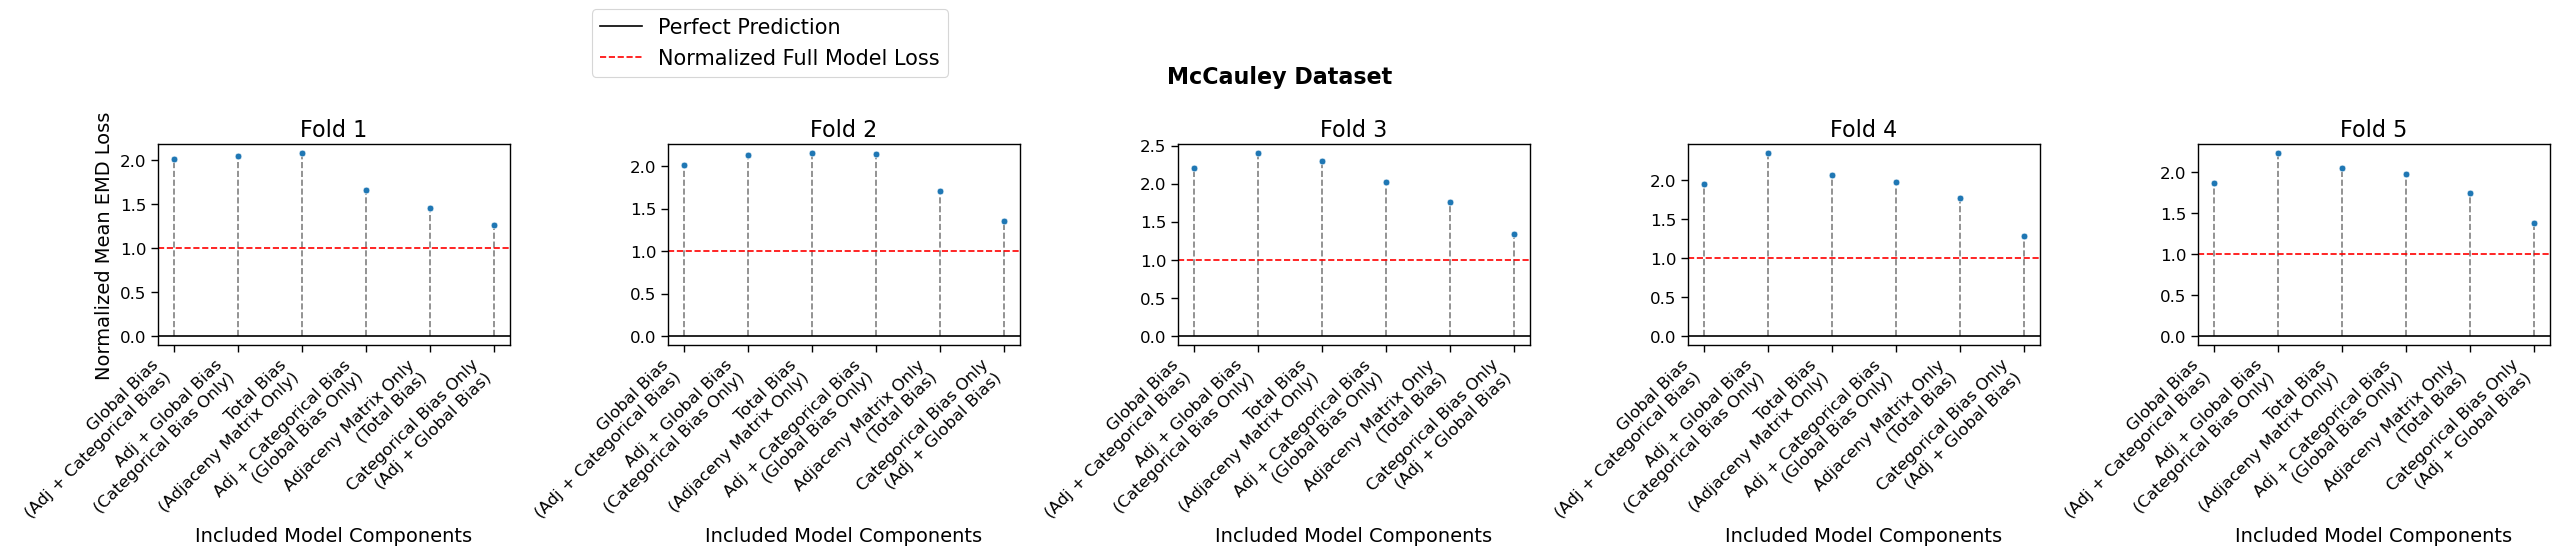

In [20]:
with sns.plotting_context(
    "paper",font_scale = 1.2,
    rc={
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 15,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
):

    ncols = 5
    fig, ax = plt.subplots(
        ncols=ncols,
        nrows=1,
        figsize=(5.1*ncols, 5.1),
        constrained_layout=True
    )
    fig.set_constrained_layout_pads(h_pad=0.15, w_pad=0.05, hspace=0.15)

    space = "Full Feature Space"

    # ---- filter for the single space ----
    viz_df = emd_loss[emd_loss.Space == space].copy()
    viz_df = viz_df[~viz_df["Model Components"].isin([ar_c['none']])].copy()
    viz_df["Model Components"] = viz_df["Model Components"].cat.remove_unused_categories()

    for j in range(ncols):
        fold = j + 1
        viz_df_fold = viz_df[viz_df.Fold == fold]
        sns.scatterplot(
            data=viz_df_fold,
            x="Model Components",
            y="Normalized Mean EMD Loss",
            ax=ax[j]
        )
        ax[j].tick_params(axis="x", rotation=45)
        for label in ax[j].get_xticklabels():
            label.set_ha("right")
        ax[j].axhline(y=0, color="black", label="Perfect Prediction")
        ax[j].axhline(y=1, color="red", linestyle="--", label="Normalized Full Model Loss")
        for x, y in zip(
            viz_df_fold["Model Components"],
            viz_df_fold["Normalized Mean EMD Loss"]
        ):
            ax[j].vlines(x, ymin=0, ymax=y, linestyle="dashed", color="gray", zorder=0)
        ax[j].set_title(f"Fold {fold}")
        ax[j].set_xlabel("Included Model Components")
        if j == 0:
            ax[j].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        if j != 0:
            ax[j].set_ylabel('')

    # ---- shared legend ----
    leg = ax[0].get_legend()
    handles = leg.legend_handles
    labels = [t.get_text() for t in leg.get_texts()]
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.3, 1.1)
    )
    ax[0].legend_.remove()
    fig.suptitle('McCauley Dataset', fontsize = 16, fontweight = 'bold')
    fig.savefig(os.path.join(data_path, 'figures', '{}_individual_component_per_fold.png'.format(author)), dpi=600, bbox_inches='tight')

    ;